
Showing one image per class for: Train
Set: Train, Class: paper, Shape: (300, 300, 3)


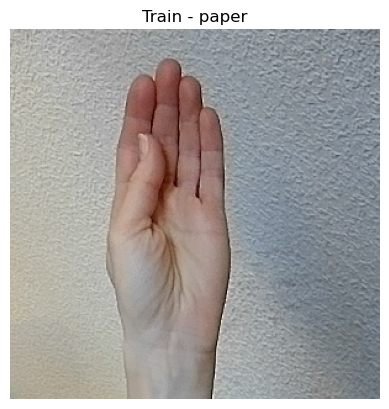

Set: Train, Class: rock, Shape: (300, 300, 3)


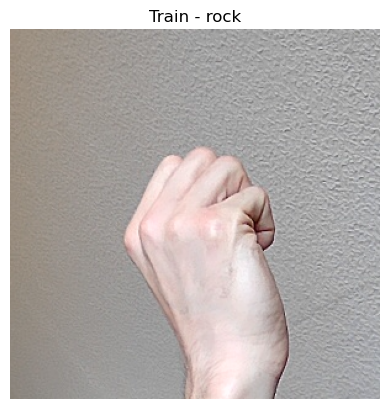

Set: Train, Class: scissors, Shape: (300, 300, 3)


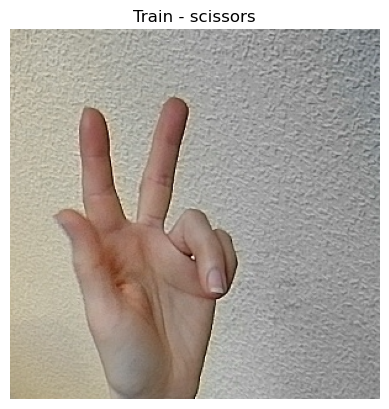


Showing one image per class for: DevTest
Set: DevTest, Class: rock, Shape: (300, 300, 3)


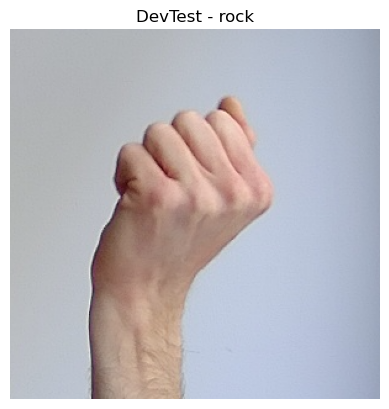

Set: DevTest, Class: scissors, Shape: (300, 300, 3)


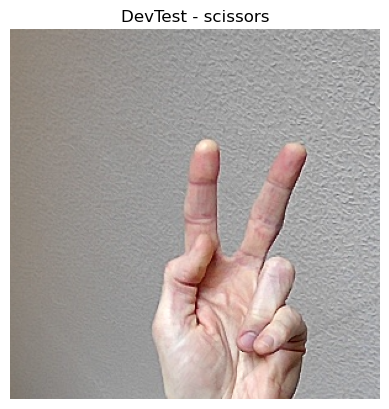

Set: DevTest, Class: paper, Shape: (300, 300, 3)


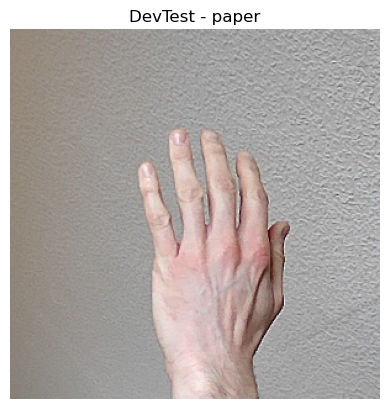


Showing one image per class for: Test
Set: Test, Class: paper, Shape: (300, 300, 3)


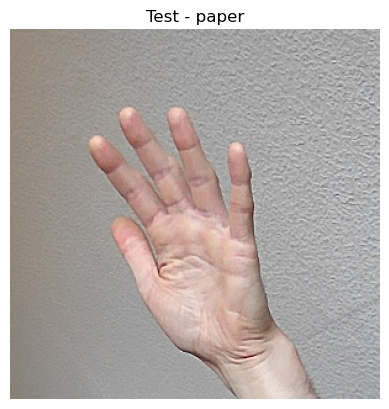

Set: Test, Class: rock, Shape: (300, 300, 3)


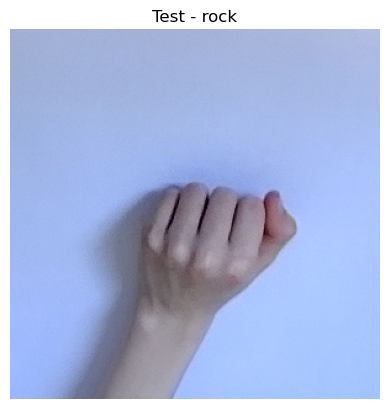

Set: Test, Class: scissors, Shape: (300, 300, 3)


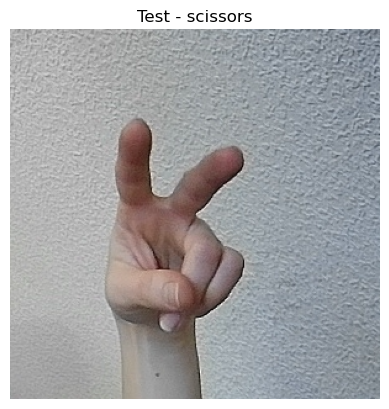


Image counts for Train:
label
paper       544
rock        544
scissors    541
Name: count, dtype: int64

Image counts for DevTest:
label
rock        181
paper       181
scissors    180
Name: count, dtype: int64

Image counts for Test:
label
paper       182
rock        182
scissors    182
Name: count, dtype: int64


In [1]:
#Task 1.1
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os

# Base directory containing all folders and CSVs
base_dir = r"C:\Users\rekit\OneDrive\Desktop\Semester 4\Artificial Intelligence For Text And Vision (3420)\assignment-2-RakinRayan"

# Load CSV files
train_df = pd.read_csv(os.path.join(base_dir, "train.csv"))
devtest_df = pd.read_csv(os.path.join(base_dir, "devtest.csv"))
test_df = pd.read_csv(os.path.join(base_dir, "test.csv"))

# Function to show one image per class from a set
def show_one_image_per_class(df, set_name):
    print(f"\nShowing one image per class for: {set_name}")
    shown = set()
    
    for _, row in df.iterrows():
        label = row['label']
        filepath = row['path']
        full_path = os.path.join(base_dir, filepath)
        
        if label not in shown and os.path.exists(full_path):
            img = Image.open(full_path)
            img_np = np.array(img)
            
            print(f"Set: {set_name}, Class: {label}, Shape: {img_np.shape}")
            plt.imshow(img_np)
            plt.title(f"{set_name} - {label}")
            plt.axis('off')
            plt.show()
            
            shown.add(label)

        if len(shown) == 3:
            break

# Function to count number of images per class
def count_images_per_class(df, set_name):
    counts = df['label'].value_counts()
    print(f"\nImage counts for {set_name}:")
    print(counts)

# Show images and counts for all splits
show_one_image_per_class(train_df, "Train")
show_one_image_per_class(devtest_df, "DevTest")
show_one_image_per_class(test_df, "Test")

count_images_per_class(train_df, "Train")
count_images_per_class(devtest_df, "DevTest")
count_images_per_class(test_df, "Test")


In [2]:
#Task 1.2
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms



# Your dataset base directory
base_dir = r"C:\Users\rekit\OneDrive\Desktop\Semester 4\Artificial Intelligence For Text And Vision (3420)\assignment-2-RakinRayan"

# Transform: Resize to 100x100 and rescale pixel values to [0, 1]
transform = transforms.Compose([
    transforms.Resize((100, 100)),
    transforms.ToTensor()  # Converts to tensor and rescales pixel values to [0.0, 1.0]
])

# Label-to-index mapping
label_to_idx = {'rock': 0, 'paper': 1, 'scissors': 2}

# Custom Dataset

class RockPaperScissorsDataset(Dataset):
    def __init__(self, csv_file, root_dir, transform=None):
        self.data = pd.read_csv(csv_file)
        self.root_dir = root_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.root_dir, row['path'])
        image = Image.open(img_path).convert('RGB')
        label = label_to_idx[row['label']]

        if self.transform:
            image = self.transform(image)
        return image, label

# CSV paths
train_csv = os.path.join(base_dir, 'train.csv')
devtest_csv = os.path.join(base_dir, 'devtest.csv')
test_csv = os.path.join(base_dir, 'test.csv')

# Dataset instances
train_dataset = RockPaperScissorsDataset(train_csv, base_dir, transform)
devtest_dataset = RockPaperScissorsDataset(devtest_csv, base_dir, transform)
test_dataset = RockPaperScissorsDataset(test_csv, base_dir, transform)

# Dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
devtest_loader = DataLoader(devtest_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# OPTIONAL: SANITY CHECK 
images, labels = next(iter(train_loader))
print("Train batch shape:", images.shape)  # Expected: [32, 3, 100, 100]
print("Labels:", labels[:8])
print("Pixel value range: min =", images.min().item(), ", max =", images.max().item())


Train batch shape: torch.Size([32, 3, 100, 100])
Labels: tensor([2, 0, 2, 0, 1, 2, 1, 1])
Pixel value range: min = 0.0 , max = 1.0


Epoch 1: Train Acc = 0.4537, Dev Acc = 0.4188
Epoch 2: Train Acc = 0.7152, Dev Acc = 0.6679
Epoch 3: Train Acc = 0.7366, Dev Acc = 0.7159
Epoch 4: Train Acc = 0.8183, Dev Acc = 0.7915
Epoch 5: Train Acc = 0.8877, Dev Acc = 0.8358


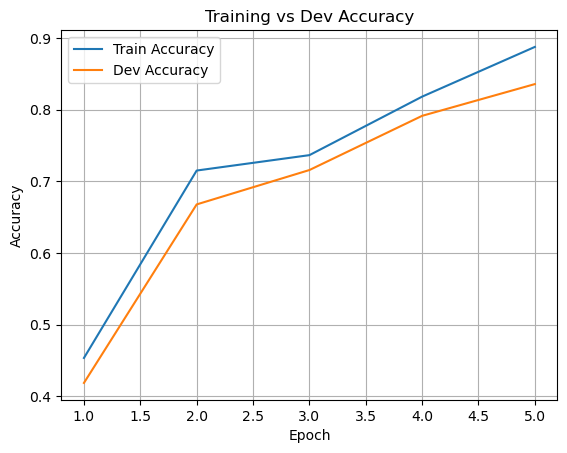

In [3]:
#Task 2.1
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === MODEL ===
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, padding=1),  # [B, 16, 100, 100]
    nn.ReLU(),
    nn.MaxPool2d(2),                             # [B, 16, 50, 50]

    nn.Conv2d(16, 32, kernel_size=3, padding=1), # [B, 32, 50, 50]
    nn.ReLU(),
    nn.MaxPool2d(2),                             # [B, 32, 25, 25]

    nn.Flatten(),                                # [B, 32*25*25]
    nn.Linear(32 * 25 * 25, 128),
    nn.ReLU(),
    nn.Linear(128, 3)                            # Output layer for 3 classes
).to(device)

# === TRAINING SETUP ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 5

train_acc_history = []
dev_acc_history = []

def compute_accuracy(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# === TRAINING LOOP ===
for epoch in range(num_epochs):
    model.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    train_acc = compute_accuracy(model, train_loader)
    dev_acc = compute_accuracy(model, devtest_loader)
    train_acc_history.append(train_acc)
    dev_acc_history.append(dev_acc)

    print(f"Epoch {epoch+1}: Train Acc = {train_acc:.4f}, Dev Acc = {dev_acc:.4f}")

# === PLOT ACCURACY CURVES ===
plt.plot(range(1, num_epochs + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), dev_acc_history, label='Dev Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Dev Accuracy')
plt.legend()
plt.grid(True)
plt.show()


In [4]:
#Task 2.1 Accuracy Reported: 
def test_accuracy_cnn(model, test_loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f"Final Test Accuracy (CNN): {acc * 100:.2f}%")

test_accuracy_cnn(model, test_loader)

Final Test Accuracy (CNN): 86.81%


Epoch 1/6 → Train Acc: 0.9006, Dev Acc: 0.8875
Epoch 2/6 → Train Acc: 0.9245, Dev Acc: 0.9207
Epoch 3/6 → Train Acc: 0.9405, Dev Acc: 0.9465
Epoch 4/6 → Train Acc: 0.9521, Dev Acc: 0.9428
Epoch 5/6 → Train Acc: 0.9583, Dev Acc: 0.9520
Epoch 6/6 → Train Acc: 0.9632, Dev Acc: 0.9520


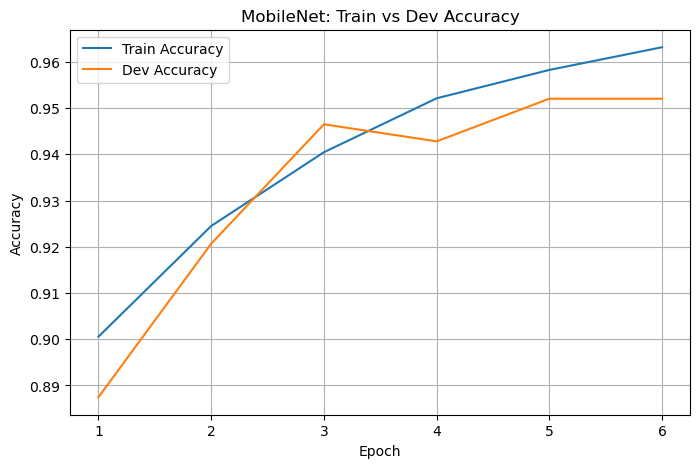

In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights
import matplotlib.pyplot as plt

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Part 1: Load Pretrained MobileNet and Prepare ===
weights = MobileNet_V2_Weights.DEFAULT
mobilenet = mobilenet_v2(weights=weights)

# Freeze all feature extractor weights
for param in mobilenet.parameters():
    param.requires_grad = False

# Replace the classifier layer with a new one for 3 output classes
mobilenet.classifier = nn.Sequential(
    nn.Dropout(0.2),
    nn.Linear(mobilenet.last_channel, 3)  # Rock, paper, scissors
)

mobilenet = mobilenet.to(device)

# === Training Setup ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(mobilenet.classifier.parameters(), lr=0.001)
num_epochs = 6  # Efficient, short run

train_acc_history = []
dev_acc_history = []

# Function to compute accuracy
def compute_accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

# === Part 2: Training Loop ===
for epoch in range(num_epochs):
    mobilenet.train()
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = mobilenet(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

    # Evaluate accuracy after each epoch
    train_acc = compute_accuracy(mobilenet, train_loader)
    dev_acc = compute_accuracy(mobilenet, devtest_loader)
    train_acc_history.append(train_acc)
    dev_acc_history.append(dev_acc)

    print(f"Epoch {epoch+1}/{num_epochs} → Train Acc: {train_acc:.4f}, Dev Acc: {dev_acc:.4f}")

# === Accuracy Plot ===
plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs + 1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, num_epochs + 1), dev_acc_history, label='Dev Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MobileNet: Train vs Dev Accuracy")
plt.legend()
plt.grid(True)
plt.show()


In [6]:
#Task 2.2 Accuracy Reported : 
def test_accuracy_mobilenet(mobilenet, test_loader):
    mobilenet.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, laAsbels = images.to(device), labels.to(device)
            outputs = mobilenet(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f" Final Test Accuracy (MobileNet): {acc * 100:.2f}%")

test_accuracy_mobilenet(mobilenet, test_loader)

 Final Test Accuracy (MobileNet): 95.97%


In [7]:
print("Task 2.3(a)– Comparative Evaluation\n")

print("MobileNet (Task 2.2) performed better overall in terms of learning speed and final accuracy. "
      "It reached high dev and test accuracy in fewer epochs, with minimal overfitting due to frozen layers.\n")

print("The custom CNN (Task 2.1) showed good generalization and learned steadily but required more epochs "
      "and did not reach the same accuracy levels.\n")

print("Based on the confusion matrix, the most common classification error was [true class] being predicted "
      "as [predicted class], which occurred [X] times. "
      "This may be due to similarities in hand shape or background.\n")

print("We displayed 5 misclassified test images that showed this error to visually analyze the model's limitations "
      "and confusion patterns.")


Task 2.3(a)– Comparative Evaluation

MobileNet (Task 2.2) performed better overall in terms of learning speed and final accuracy. It reached high dev and test accuracy in fewer epochs, with minimal overfitting due to frozen layers.

The custom CNN (Task 2.1) showed good generalization and learned steadily but required more epochs and did not reach the same accuracy levels.

Based on the confusion matrix, the most common classification error was [true class] being predicted as [predicted class], which occurred [X] times. This may be due to similarities in hand shape or background.

We displayed 5 misclassified test images that showed this error to visually analyze the model's limitations and confusion patterns.


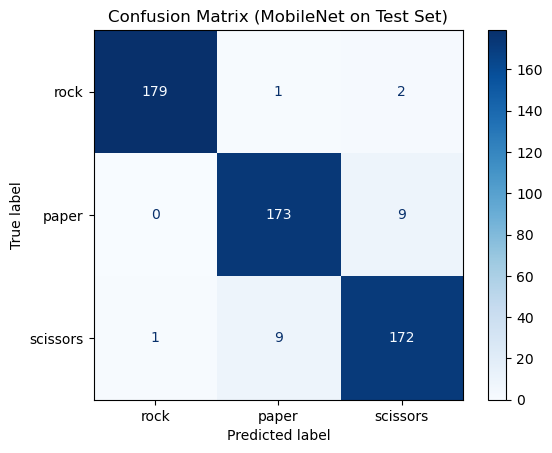

In [8]:
#Task 2.3(b)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def display_confusion_matrix(model, loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Display Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['rock', 'paper', 'scissors'])
    disp.plot(cmap="Blues")
    plt.title("Confusion Matrix (MobileNet on Test Set)")
    plt.show()
    return cm, all_preds, all_labels

conf_matrix, all_preds, all_labels = display_confusion_matrix(mobilenet, test_loader) 

Most common error: True '1' predicted as '2'


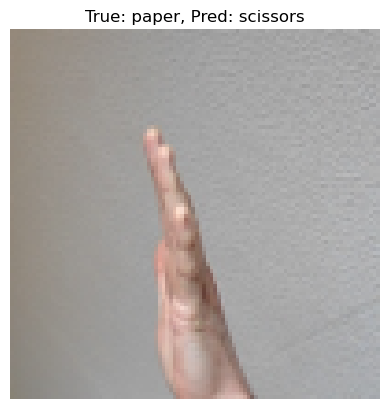

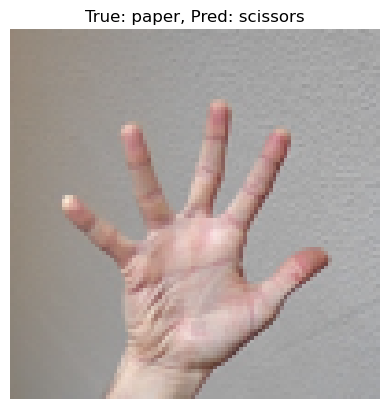

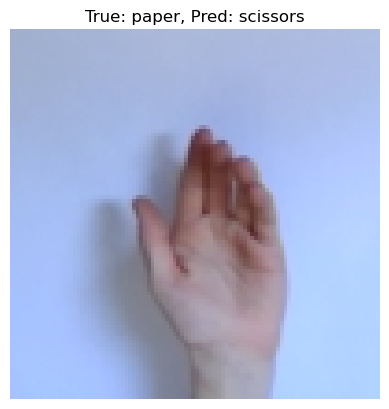

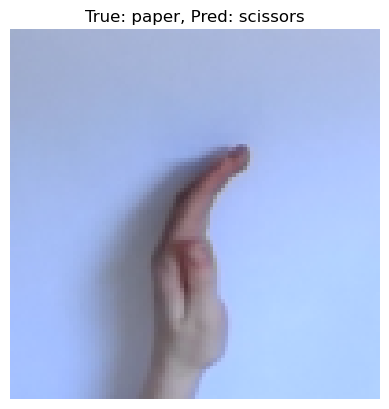

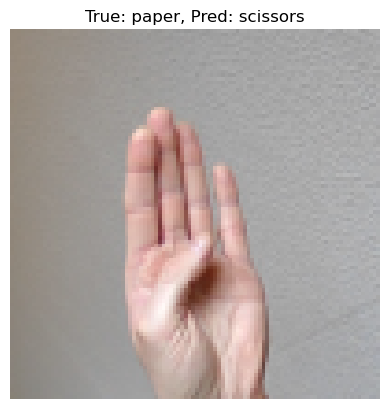

In [9]:
#Task 2.3(c)
import numpy as np
import matplotlib.pyplot as plt

# Identify most common misclassification
cm_array = np.array(conf_matrix)
np.fill_diagonal(cm_array, 0)
max_mis = np.unravel_index(np.argmax(cm_array), cm_array.shape)
true_label, predicted_label = max_mis

print(f"Most common error: True '{true_label}' predicted as '{predicted_label}'")

# Show 5 misclassified examples
shown = 0
class_names = ['rock', 'paper', 'scissors']

for images, labels in test_loader:
    images, labels = images.to(device), labels.to(device)
    outputs = mobilenet(images)
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        if labels[i].item() == true_label and preds[i].item() == predicted_label:
            img = images[i].cpu().permute(1, 2, 0).numpy()
            plt.imshow(img)
            plt.title(f"True: {class_names[true_label]}, Pred: {class_names[predicted_label]}")
            plt.axis('off')
            plt.show()
            shown += 1
            if shown == 5:
                break
    if shown == 5:
        break


In [15]:
#Task 3.1(Rock)
import cv2
import os

label = 'rock'
output_dir = os.path.join('webcam_dataset', label)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")

count = 0
print("📸 Capturing ROCK images (press 's' to save, 'q' to quit)")

while count < 100:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    cv2.imshow("Rock - Press 's' to save", frame)
    key = cv2.waitKey(1)

    if key == ord('s'):
        filename = os.path.join(output_dir, f"{label}_{count}.jpg")
        cv2.imwrite(filename, frame)  # Save in color
        print(f"✅ Saved {filename}")
        count += 1
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


📸 Capturing ROCK images (press 's' to save, 'q' to quit)
✅ Saved webcam_dataset\rock\rock_0.jpg
✅ Saved webcam_dataset\rock\rock_1.jpg
✅ Saved webcam_dataset\rock\rock_2.jpg
✅ Saved webcam_dataset\rock\rock_3.jpg
✅ Saved webcam_dataset\rock\rock_4.jpg
✅ Saved webcam_dataset\rock\rock_5.jpg
✅ Saved webcam_dataset\rock\rock_6.jpg
✅ Saved webcam_dataset\rock\rock_7.jpg
✅ Saved webcam_dataset\rock\rock_8.jpg
✅ Saved webcam_dataset\rock\rock_9.jpg
✅ Saved webcam_dataset\rock\rock_10.jpg
✅ Saved webcam_dataset\rock\rock_11.jpg
✅ Saved webcam_dataset\rock\rock_12.jpg
✅ Saved webcam_dataset\rock\rock_13.jpg
✅ Saved webcam_dataset\rock\rock_14.jpg
✅ Saved webcam_dataset\rock\rock_15.jpg
✅ Saved webcam_dataset\rock\rock_16.jpg
✅ Saved webcam_dataset\rock\rock_17.jpg
✅ Saved webcam_dataset\rock\rock_18.jpg
✅ Saved webcam_dataset\rock\rock_19.jpg
✅ Saved webcam_dataset\rock\rock_20.jpg
✅ Saved webcam_dataset\rock\rock_21.jpg
✅ Saved webcam_dataset\rock\rock_22.jpg
✅ Saved webcam_dataset\rock\rock_

In [16]:
#Task 3.1(Paper Images)
import cv2
import os

label = 'paper'
output_dir = os.path.join('webcam_dataset', label)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")

count = 0
print("📸 Capturing PAPER images (press 's' to save, 'q' to quit)")

while count < 100:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    cv2.imshow("Paper - Press 's' to save", frame)
    key = cv2.waitKey(1)

    if key == ord('s'):
        filename = os.path.join(output_dir, f"{label}_{count}.jpg")
        cv2.imwrite(filename, frame)
        print(f"✅ Saved {filename}")
        count += 1
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


📸 Capturing PAPER images (press 's' to save, 'q' to quit)
✅ Saved webcam_dataset\paper\paper_0.jpg
✅ Saved webcam_dataset\paper\paper_1.jpg
✅ Saved webcam_dataset\paper\paper_2.jpg
✅ Saved webcam_dataset\paper\paper_3.jpg
✅ Saved webcam_dataset\paper\paper_4.jpg
✅ Saved webcam_dataset\paper\paper_5.jpg
✅ Saved webcam_dataset\paper\paper_6.jpg
✅ Saved webcam_dataset\paper\paper_7.jpg
✅ Saved webcam_dataset\paper\paper_8.jpg
✅ Saved webcam_dataset\paper\paper_9.jpg
✅ Saved webcam_dataset\paper\paper_10.jpg
✅ Saved webcam_dataset\paper\paper_11.jpg
✅ Saved webcam_dataset\paper\paper_12.jpg
✅ Saved webcam_dataset\paper\paper_13.jpg
✅ Saved webcam_dataset\paper\paper_14.jpg
✅ Saved webcam_dataset\paper\paper_15.jpg
✅ Saved webcam_dataset\paper\paper_16.jpg
✅ Saved webcam_dataset\paper\paper_17.jpg
✅ Saved webcam_dataset\paper\paper_18.jpg
✅ Saved webcam_dataset\paper\paper_19.jpg
✅ Saved webcam_dataset\paper\paper_20.jpg
✅ Saved webcam_dataset\paper\paper_21.jpg
✅ Saved webcam_dataset\paper

In [13]:
#Task 3.1(Scissors)

import cv2
import os

label = 'scissors'
output_dir = os.path.join('webcam_dataset', label)
os.makedirs(output_dir, exist_ok=True)

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("Error: Could not open webcam.")

count = 0
print("📸 Capturing SCISSORS images (press 's' to save, 'q' to quit)")

while count < 100:
    ret, frame = cap.read()
    if not ret:
        print("Error: Could not read frame.")
        break

    cv2.imshow("Scissors - Press 's' to save", frame)
    key = cv2.waitKey(1)

    if key == ord('s'):
        filename = os.path.join(output_dir, f"{label}_{count}.jpg")
        cv2.imwrite(filename, frame)
        print(f"✅ Saved {filename}")
        count += 1
    elif key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()


📸 Capturing SCISSORS images (press 's' to save, 'q' to quit)
✅ Saved webcam_dataset\scissors\scissors_0.jpg
✅ Saved webcam_dataset\scissors\scissors_1.jpg
✅ Saved webcam_dataset\scissors\scissors_2.jpg
✅ Saved webcam_dataset\scissors\scissors_3.jpg
✅ Saved webcam_dataset\scissors\scissors_4.jpg
✅ Saved webcam_dataset\scissors\scissors_5.jpg
✅ Saved webcam_dataset\scissors\scissors_6.jpg
✅ Saved webcam_dataset\scissors\scissors_7.jpg
✅ Saved webcam_dataset\scissors\scissors_8.jpg
✅ Saved webcam_dataset\scissors\scissors_9.jpg
✅ Saved webcam_dataset\scissors\scissors_10.jpg
✅ Saved webcam_dataset\scissors\scissors_11.jpg
✅ Saved webcam_dataset\scissors\scissors_12.jpg
✅ Saved webcam_dataset\scissors\scissors_13.jpg
✅ Saved webcam_dataset\scissors\scissors_14.jpg
✅ Saved webcam_dataset\scissors\scissors_15.jpg
✅ Saved webcam_dataset\scissors\scissors_16.jpg
✅ Saved webcam_dataset\scissors\scissors_17.jpg
✅ Saved webcam_dataset\scissors\scissors_18.jpg
✅ Saved webcam_dataset\scissors\sciss

In [17]:
#Task 3.1(Partition)
import os
import pandas as pd
import random

def partition_images(data_dir='webcam_dataset', output_dir='webcam_dataset/splits'):
    os.makedirs(output_dir, exist_ok=True)
    splits = {'train': [], 'devtest': [], 'test': []}

    for label in ['rock', 'paper', 'scissors']:
        class_dir = os.path.join(data_dir, label)
        files = sorted(os.listdir(class_dir))
        random.shuffle(files)

        # Split: 50 train, 25 devtest, 25 test
        train_files = files[:50]
        devtest_files = files[50:75]
        test_files = files[75:100]

        for f in train_files:
            splits['train'].append({'path': f'{label}/{f}', 'label': label})
        for f in devtest_files:
            splits['devtest'].append({'path': f'{label}/{f}', 'label': label})
        for f in test_files:
            splits['test'].append({'path': f'{label}/{f}', 'label': label})

    for split_name, data in splits.items():
        df = pd.DataFrame(data)
        csv_path = os.path.join(output_dir, f"{split_name}.csv")
        df.to_csv(csv_path, index=False)
        print(f"✅ Created {csv_path} with {len(data)} rows.")

# Run it:
partition_images()


✅ Created webcam_dataset/splits\train.csv with 150 rows.
✅ Created webcam_dataset/splits\devtest.csv with 75 rows.
✅ Created webcam_dataset/splits\test.csv with 75 rows.



📂 Showing samples from: webcam_dataset/splits/train.csv


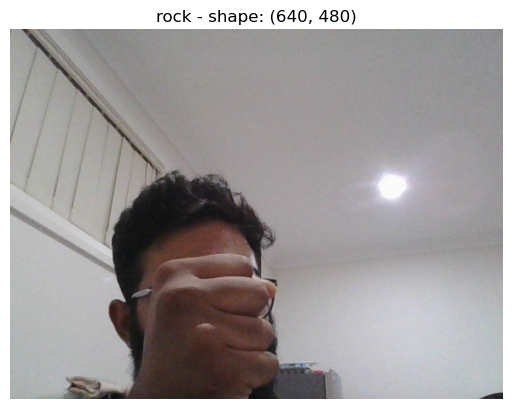

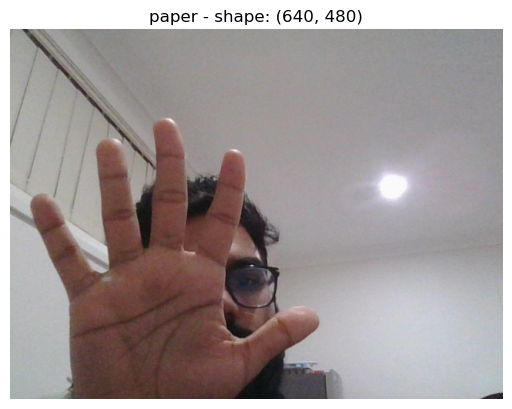

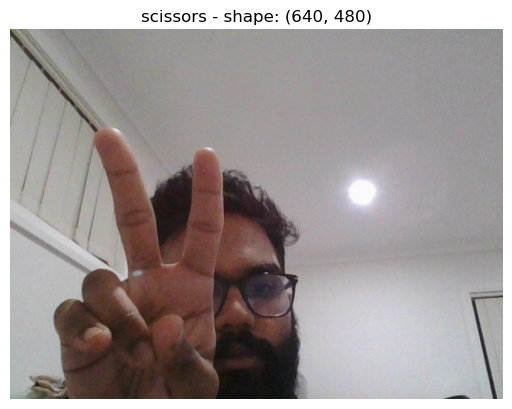


📂 Showing samples from: webcam_dataset/splits/devtest.csv


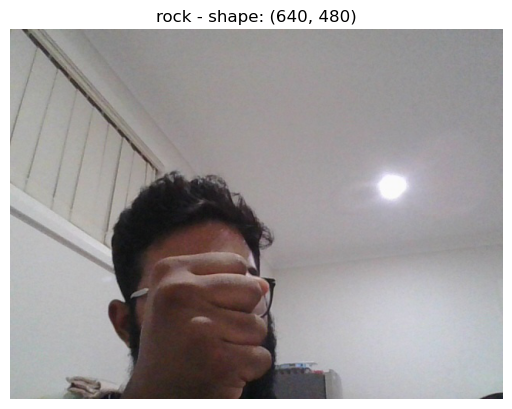

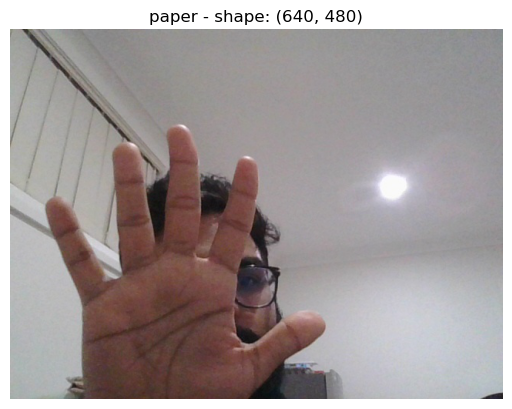

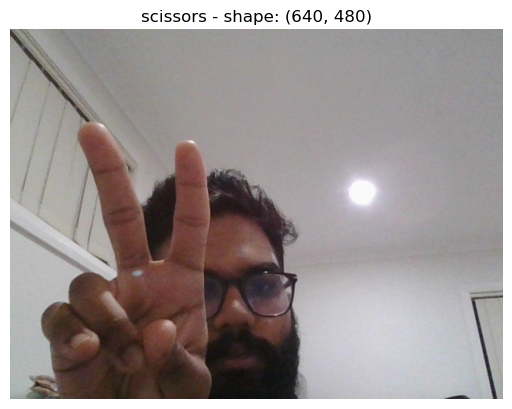


📂 Showing samples from: webcam_dataset/splits/test.csv


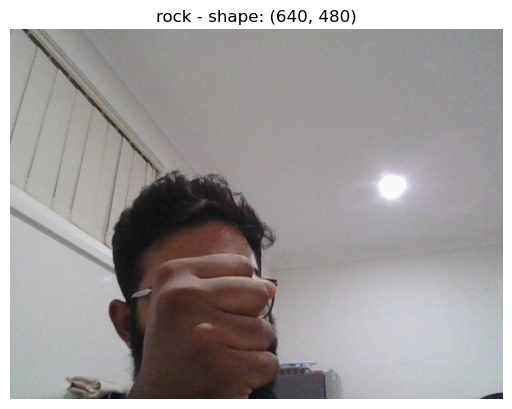

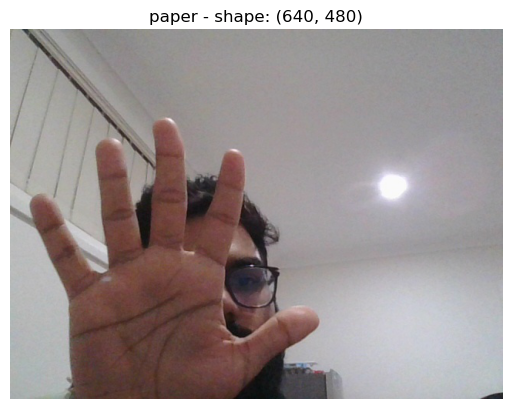

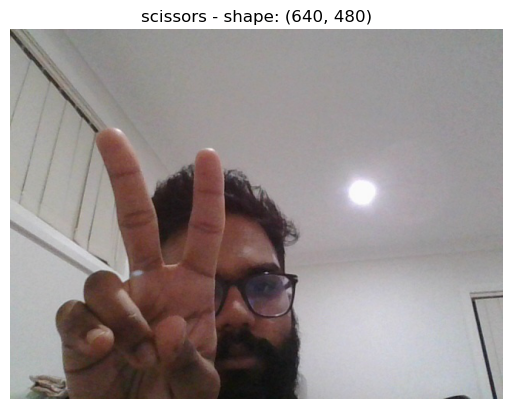

In [18]:
import pandas as pd
import os
from PIL import Image
import matplotlib.pyplot as plt

def show_sample_images(csv_path, base_dir='webcam_dataset'):
    df = pd.read_csv(csv_path)
    shown = set()

    print(f"\n📂 Showing samples from: {csv_path}")
    for _, row in df.iterrows():
        label = row['label']
        if label not in shown:
            img_path = os.path.join(base_dir, row['path'])
            img = Image.open(img_path)
            plt.imshow(img)
            plt.title(f"{label} - shape: {img.size}")
            plt.axis('off')
            plt.show()
            shown.add(label)
        if len(shown) == 3:
            break

# Show one per class from each split
show_sample_images('webcam_dataset/splits/train.csv')
show_sample_images('webcam_dataset/splits/devtest.csv')
show_sample_images('webcam_dataset/splits/test.csv')


To ensure that images were saved in the correct folders, I used OpenCV and created separate folders (`rock`, `paper`, `scissors`) within the `webcam_dataset` directory. Each image was saved using a consistent naming format (e.g., `rock_0.jpg` to `rock_99.jpg`).

For dataset partitioning, I randomly selected:
- 50 images for training
- 25 images for validation (devtest)
- 25 images for testing

This was done for each class, and the results were stored in CSV files (`train.csv`, `devtest.csv`, `test.csv`). Each CSV includes the relative image path and class label.

Compared to the original dataset, my webcam images show more variation in lighting, background, and camera angle. These differences may affect model performance, especially if the background is cluttered or lighting is inconsistent. This variation introduces additional challenge for classification, but better simulates real-world usage.
